In [1]:
import pandas as pd

salaries = pd.read_csv('../datasets/ds_salaries_clean.csv')

# Addressing missing data

- In this context, referring to samples that are not representative of the population, rather than "missing data", really...
- But then the methods described are actually referring to *missing values* in the dataset sense. Ugh.
## Strategies for addressing missing data
- Drop missing values
    - Particularly if 5% or less of total values
- Impute with mean, median, or mode if more than 5% of total values
    - Depends on distribution and context

In [2]:
import numpy as np
import pandas as pd

def introduce_missing(df, frac=0.1, columns=None, exclude=None, seed=None):
    """Randomly replace cells with NaN to simulate missing data.

    Parameters
    ----------
    df : pd.DataFrame
        Input frame. Not modified in place.
    frac : float or dict
        Fraction of cells per column to blank out. Pass a dict for
        per-column rates, e.g. {'age': 0.2, 'income': 0.05}.
    columns : list, optional
        If given, only these columns are eligible for wiping.
    exclude : list, optional
        Columns to leave untouched (targets, IDs, etc.).
    seed : int, optional
        For reproducibility.

    Returns
    -------
    pd.DataFrame
        A copy of df with NaNs inserted.
    """
    rng = np.random.default_rng(seed)
    out = df.copy()

    eligible = list(columns) if columns is not None else list(df.columns)
    if exclude:
        eligible = [c for c in eligible if c not in exclude]

    frac_map = frac if isinstance(frac, dict) else {c: frac for c in eligible}

    n = len(out)
    for col, p in frac_map.items():
        if col not in out.columns:
            continue
        k = min(int(round(p * n)), n)
        positions = rng.choice(n, size=k, replace=False)
        out.loc[out.index[positions], col] = np.nan

    return out

messy_salaries = introduce_missing(salaries)

In [ ]:
def impute_missing(data):
    """ Returns the dataset with columns dropped if less than 5% of total, or with appropriate summary by datatype"""
    threshold = len(data) * 0.05
    cols_to_drop = data.columns[data.isna().sum() <= threshold]
    new_data = data.drop(cols_to_drop)
    cols_with_missing = data.columns[data.isna().sum() > 0]
    print(cols_with_missing)
    for col in cols_with_missing:
        if type(col) == type('string'):
            new_data[col].fillna(data[col].mode()[0])
        else:
            new_data[col].fillna(data[col].mean()[0])
    return new_data


print(messy_salaries.info())


<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Working_Year          546 non-null    float64
 1   Designation           546 non-null    str    
 2   Experience            546 non-null    str    
 3   Employment_Status     546 non-null    str    
 4   Employee_Location     546 non-null    str    
 5   Company_Size          546 non-null    str    
 6   Remote_Working_Ratio  546 non-null    float64
 7   Salary_USD            546 non-null    float64
dtypes: float64(3), str(5)
memory usage: 38.1 KB
None
Index(['Working_Year', 'Designation', 'Experience', 'Employment_Status',
       'Employee_Location', 'Company_Size', 'Remote_Working_Ratio',
       'Salary_USD'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------      

Index(['Working_Year', 'Designation', 'Experience', 'Employment_Status',
       'Employee_Location', 'Company_Size', 'Remote_Working_Ratio',
       'Salary_USD'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Working_Year          546 non-null    float64
 1   Designation           546 non-null    str    
 2   Experience            546 non-null    str    
 3   Employment_Status     546 non-null    str    
 4   Employee_Location     546 non-null    str    
 5   Company_Size          546 non-null    str    
 6   Remote_Working_Ratio  546 non-null    float64
 7   Salary_USD            546 non-null    float64
dtypes: float64(3), str(5)
memory usage: 38.1 KB
None


# Converting and analyzing categorical data
- use `df.select_dtypes("object")` to filter non-numerical data
- use `df['col'].value_counts()` to find the frequency of values
- use `df['col'].nunique()` to find the number of unique job titles

In [3]:
salaries.select_dtypes("str").head()

,Designation,Experience,Employment_Status,Employee_Location,Company_Size
0,Data Scientist,Mid,FT,DE,L
1,Machine Learning Scientist,Senior,FT,JP,S
2,Big Data Engineer,Senior,FT,GB,M
3,Product Data Analyst,Mid,FT,HN,S
4,Machine Learning Engineer,Senior,FT,US,L


In [ ]:
#%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

top_5_designations = salaries['Designation'].value_counts().head()
top_5_designations.plot(kind='bar')
plt.xticks(rotation = 45)
plt.show()

## Extracting value from categories
- use `pd.series.str.contains()`
- Ex. which titles don't have "Data" in them?
- Finding multiple phrases in strings
    - Use `pd.series.str.contains("A|B")`
- Finding values with a particular string at the start
    - Use `pd.series.str.contains("^Data")`

In [5]:
print(salaries[~salaries["Designation"].str.contains("Data")]["Designation"].value_counts().head(),"\n")
print(salaries[salaries["Designation"].str.contains("Engineer|Scientist")]["Designation"].value_counts().head())

Designation
Machine Learning Engineer     41
Research Scientist            16
Machine Learning Scientist     8
AI Scientist                   7
ML Engineer                    6
Name: count, dtype: int64 

Designation
Data Scientist                143
Data Engineer                 132
Machine Learning Engineer      41
Research Scientist             16
Machine Learning Scientist      8
Name: count, dtype: int64


## Finding multiple phrases (advanced)

In [6]:
job_categories = ["Data Science", "Data Analytics", "Data Engineering", "Machine Learning", "Managerial", "Consultant"]
data_science = "Data Scientist|NLP"
data_analyst = "Analyst|Analytics"
data_engineer = "Data Engineer|ETL|Architect|Infrastructure"
ml_engineer = "Machine Learning|ML|Big Data|AI"
manager = "Manager|Head|Director|Lead|Principal|Staff"
consultant = "Consultant|Freelance"

# create a list of conditions for each category
conditions = [
    salaries["Designation"].str.contains(data_science, case=False, na=False),
    salaries["Designation"].str.contains(data_analyst, case=False, na=False),
    salaries["Designation"].str.contains(data_engineer, case=False, na=False),
    salaries["Designation"].str.contains(ml_engineer, case=False, na=False),
    salaries["Designation"].str.contains(manager, case=False, na=False),
    salaries["Designation"].str.contains(consultant, case=False, na=False)
]

- Using `np.select`
    - List of conditions as the first argument, list of arrays to search for conditions in the second, pass default values to asssign when a different value is found

In [7]:
salaries["Job_Category"] = np.select(conditions, job_categories, default="Other")

In [8]:
print(salaries[["Designation","Job_Category"]].head())

                  Designation      Job_Category
0              Data Scientist      Data Science
1  Machine Learning Scientist  Machine Learning
2           Big Data Engineer  Data Engineering
3        Product Data Analyst    Data Analytics
4   Machine Learning Engineer  Machine Learning


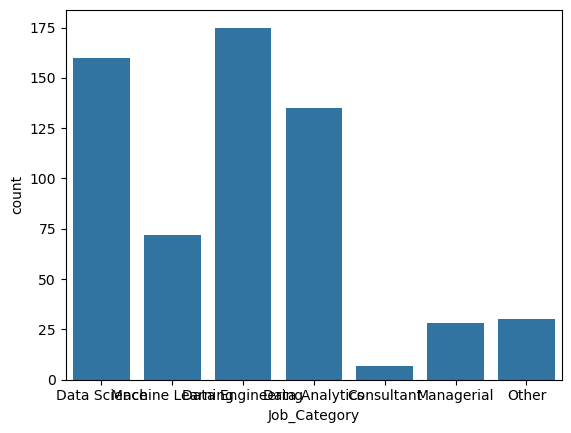

In [9]:
sns.countplot(data=salaries, x="Job_Category")
plt.show()

# Working with numeric data
## Converting strings to numbers
- Ex. `salaries["Salary_In_Rupees"]` has values with commas, and object datatype. Want to convert to numbers
    - Remove commas with `series.str.replace()`
    - Modify values by conversion rate
    - Change to float (?)

In [11]:
# Create a series of values in rupees to illustrate conversion methods in a new series, using object type and commas
rupees = pd.Series(["50,000", "75,000", "100,000", "125,000", "150,000"], name="Salary_in_Rupees")
# Remove the commas
rupees_no_commas = rupees.str.replace(",", "")
# Convert to numeric type and divide by 80 to get dollars
rupees_in_dollars = rupees_no_commas.astype(float) / 80
print(rupees_in_dollars)


0     625.0
1     937.5
2    1250.0
3    1562.5
4    1875.0
Name: Salary_in_Rupees, dtype: float64


## Adding summary statistics into a DataFrame

In [10]:
# Ex1. Finding mean salary by company size as a summary table
salaries.groupby("Company_Size")["Salary_USD"].mean()

Company_Size
L    113857.282828
M    111625.328221
S     74126.313253
Name: Salary_USD, dtype: float64

- Suppose we want a new coluimn containing stdev of Salary_USD where values are conditional on experience
- Logic: Group by experience -> Select salary_usd -> Call transform() -> Apply lambda function
- Similarly for finding median salary by company size

In [11]:
salaries["std_dev"] = salaries.groupby("Experience")["Salary_USD"].transform(lambda x: x.std())
salaries["median_by_comp_size"] = salaries.groupby("Company_Size")\
    ["Salary_USD"].transform(lambda x: x.median())
salaries.head()

,Working_Year,Designation,Experience,Employment_Status,Employee_Location,Company_Size,Remote_Working_Ratio,Salary_USD,Job_Category,std_dev,median_by_comp_size
0,2020,Data Scientist,Mid,FT,DE,L,0,76227.0,Data Science,61014.876754,95483.0
1,2020,Machine Learning Scientist,Senior,FT,JP,S,0,248257.0,Machine Learning,55086.264071,62064.0
2,2020,Big Data Engineer,Senior,FT,GB,M,50,104100.0,Data Engineering,55086.264071,108076.0
3,2020,Product Data Analyst,Mid,FT,HN,S,0,19097.0,Data Analytics,61014.876754,62064.0
4,2020,Machine Learning Engineer,Senior,FT,US,L,50,143225.0,Machine Learning,55086.264071,95483.0


In [25]:
salaries.groupby("Job_Category").groups

{'Consultant': [18, 36, 91, 163, 187, 199, 272], 'Data Analytics': [3, 5, 8, 13, 14, 15, 21, 23, 28, 34, 38, 50, 51, 73, 76, 79, 80, 86, 87, 88, 89, 90, 92, 97, 100, 102, 103, 105, 118, 122, 124, 135, 140, 158, 168, 172, 183, 186, 196, 209, 219, 229, 233, 241, 249, 254, 261, 279, 290, 291, 296, 297, 305, 306, 307, 308, 318, 325, 326, 327, 328, 329, 330, 331, 332, 333, 336, 338, 339, 344, 349, 360, 361, 362, 363, 367, 368, 376, 382, 383, 387, 392, 393, 394, 395, 402, 403, 406, 408, 429, 430, 431, 440, 441, 458, 461, 470, 471, 491, 511, ...], 'Data Engineering': [2, 9, 16, 17, 19, 22, 27, 30, 31, 35, 41, 42, 43, 44, 47, 49, 53, 60, 61, 81, 85, 93, 95, 101, 107, 108, 109, 111, 112, 114, 119, 120, 121, 142, 144, 147, 148, 149, 162, 166, 169, 170, 171, 175, 180, 182, 185, 188, 192, 201, 207, 208, 212, 213, 215, 230, 232, 234, 239, 242, 245, 247, 248, 252, 255, 256, 265, 266, 267, 268, 269, 270, 280, 282, 289, 294, 295, 304, 309, 310, 313, 314, 316, 319, 320, 321, 322, 334, 335, 337, 340, 34

# Handling outliers
- Identify thresholds using quantiles (`series.quantile()`)

In [ ]:
def outlier_thresholds(series):
    """ Returns a tuple with lower outlier threshold and upper outlier threshold """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    iqr = Q3-Q1
    lower = Q1-1.5*iqr
    upper = Q3+1.5*iqr
    return (lower, upper)

def outliers(series, remove=False):
    """ If remove is false, returns a tuple of lists, first is low outliers, second is high outliers
        If remove is true, returns the series with outliers removed """
    lower, upper = outlier_thresholds(series)
    filt_low = series < lower
    filt_high = series > upper
    if remove:
        return series[~(filt_low|filt_high)]
    else:
        return (series[filt_low], series[filt_high])

low, high = outlier_thresholds(salaries["Salary_USD"])
print(salaries[(salaries["Salary_USD"]<low)|(salaries["Salary_USD"]>high)][["Experience","Employee_Location","Salary_USD"]],"\n")
print(outliers(salaries["Salary_USD"], remove=True))

    Experience Employee_Location  Salary_USD
25   Executive                US    310321.0
33         Mid                US    429675.0
63      Senior                US    393392.0
97         Mid                US    429675.0
157        Mid                US    403895.0
225  Executive                US    397211.0
252  Executive                US    572900.0
482  Executive                US    309366.0
519     Senior                US    362837.0
523     Senior                US    386708.0 

0       76227.0
1      248257.0
2      104100.0
3       19097.0
4      143225.0
         ...   
602    147044.0
603    120309.0
604    123174.0
605    143225.0
606    190967.0
Name: Salary_USD, Length: 597, dtype: float64
